# Практическая работа №4: Элементы корреляционного анализа. Проверка статистической гипотезы о равенстве коэффициента корреляции нулю

Выполнили студенты гр. 2384 Тимченко Дмитрий и Цыганков Роман.

## Цель работы

Освоение основных понятий, связанных с корреляционной зависимостью между случайными величинами, статистическими гипотезами и проверкой их справедливости.

## Основные теоретические положения

**Выборочный коэффициент корреляции Пирсона** — мера линейной зависимости между X и Y:
$$r_{вып} = \frac{\overline{xy} - \bar{x}\,\bar{y}}{\sigma_x \cdot \sigma_y}, \quad \overline{xy} = \frac{1}{n}\sum_{i,j} n_{ij}\,x_i y_j$$

**Через условные варианты** ($u_i = (x_i - C_x)/h_x$, $v_j = (y_j - C_y)/h_y$):
$$r = \frac{\bar{M}_{11} - \bar{M}_{10}\bar{M}_{01}}{\sqrt{(\bar{M}_{20} - \bar{M}_{10}^2)(\bar{M}_{02} - \bar{M}_{01}^2)}}$$

**Доверительный интервал для $\rho$** строится через преобразование Фишера:
$$z = \frac{1}{2}\ln\frac{1+r}{1-r} = \text{arctanh}(r), \quad \sigma_z = \frac{1}{\sqrt{n-3}}$$
$$z \pm z_{\gamma}\,\sigma_z \;\xrightarrow{\tanh}\; (r_1,\, r_2)$$

**Проверка гипотезы $H_0:\, \rho = 0$** против $H_1:\, \rho \neq 0$:
$$T = r\sqrt{\frac{n-2}{1-r^2}} \sim t(n-2) \text{ при } H_0$$
Гипотеза отвергается при $|T_{набл}| > t_{крит}(\alpha/2,\, n-2)$.

## Постановка задачи

Исследуется двумерная выборка объёма $n = 108$: признак **X = nu** (объёмный вес, г/см³) и признак **Y = E** (модуль упругости, кг/см²) резонансной ели. Необходимо:
1. Повторить статистическую обработку признака Y из ПР №1–2;
2. Построить двумерный интервальный ряд и корреляционную таблицу;
3. Вычислить $r$ двумя способами;
4. Построить ДИ для $\rho$ при $\gamma \in \{0.95, 0.99\}$;
5. Проверить $H_0:\, \rho = 0$ при $\alpha = 0.05$.

## Загрузка данных

In [48]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sample.csv', skiprows=3)
sample_2d = df[['nu', 'E']].head(108)
data_nu = sample_2d['nu'].values  # X
data_e  = sample_2d['E'].values   # Y
n = 108
k = 8  # число интервалов (формула Стёрджеса)

print(f'Объём выборки: n = {n}')
print(f'Число интервалов: k = {k}')
print(f'Признак X=nu: min={data_nu.min()}, max={data_nu.max()}')
print(f'Признак Y=E:  min={data_e.min()},  max={data_e.max()}')

Объём выборки: n = 108
Число интервалов: k = 8
Признак X=nu: min=320, max=593
Признак Y=E:  min=64.5,  max=187.4


## 1. Статистическая обработка признака Y = E (в объёме ПР №1–2)

Ниже воспроизводятся все основные точечные оценки для модуля упругости E, аналогично тому, как это было сделано для обоих признаков в ПР №2.

In [46]:
def build_intervals(data, n, k):
    x_min, x_max = data.min(), data.max()
    h = (x_max - x_min) / k
    bins = np.linspace(x_min, x_max, k + 1)
    m_i, mids = [], []
    for i in range(k):
        if i == k-1: c = int(np.sum((data >= bins[i]) & (data <= bins[i+1])))
        else:        c = int(np.sum((data >= bins[i]) & (data < bins[i+1])))
        m_i.append(c)
        mids.append((bins[i] + bins[i+1]) / 2)
    return np.array(bins), np.array(mids), np.array(m_i), h

def full_stats(data, n, k, label):
    bins, mids, m_i, h = build_intervals(data, n, k)
    x_bar  = np.mean(data)
    D      = np.var(data, ddof=0)
    sigma  = np.std(data, ddof=0)
    s2     = np.var(data, ddof=1)
    s      = np.std(data, ddof=1)

    m3 = np.sum(m_i * (mids - x_bar)**3) / n
    m4 = np.sum(m_i * (mids - x_bar)**4) / n
    As = m3 / sigma**3
    Ek = m4 / sigma**4 - 3
    
    idx = int(np.argmax(m_i))
    fp = m_i[idx-1] if idx > 0 else 0
    fn = m_i[idx+1] if idx < k-1 else 0
    Mo = bins[idx] + h * (m_i[idx] - fp) / ((m_i[idx] - fp) + (m_i[idx] - fn))
  
    cumf    = np.cumsum(m_i)
    med_idx = int(np.where(cumf >= n/2)[0][0])
    F_prev  = cumf[med_idx-1] if med_idx > 0 else 0
    Me = bins[med_idx] + h * (n/2 - F_prev) / m_i[med_idx]
    
    V = sigma / x_bar * 100
    print(f'Статистические характеристики признака {label}:')
    print(f'  Выборочное среднее x_bar = {x_bar:.4f}')
    print(f'  Смещённая дисперсия D_в  = {D:.4f}')
    print(f'  Исправленная дисперсия s² = {s2:.4f}')
    print(f'  Смещённое СКО sigma_в    = {sigma:.4f}')
    print(f'  Исправленное СКО s       = {s:.4f}')
    print(f'  Коэф. асимметрии As      = {As:.4f}')
    print(f'  Коэф. эксцесса Ek        = {Ek:.4f}')
    print(f'  Мода Mo*                 = {Mo:.4f}')
    print(f'  Медиана Me*              = {Me:.4f}')
    print(f'  Коэф. вариации V*        = {V:.2f}%')
    return {'x_bar': x_bar, 'D': D, 'sigma': sigma, 's': s, 'As': As,
            'Ek': Ek, 'Mo': Mo, 'Me': Me, 'V': V, 'bins': bins, 'mids': mids, 'm_i': m_i, 'h': h}

print('=' * 55)
stats_nu = full_stats(data_nu, n, k, 'X = nu (объёмный вес)')
print()
print('=' * 55)
stats_e  = full_stats(data_e,  n, k, 'Y = E (модуль упругости)')

Статистические характеристики признака X = nu (объёмный вес):
  Выборочное среднее x_bar = 449.9167
  Смещённая дисперсия D_в  = 3590.7986
  Исправленная дисперсия s² = 3624.3575
  Смещённое СКО sigma_в    = 59.9233
  Исправленное СКО s       = 60.2026
  Коэф. асимметрии As      = -0.0092
  Коэф. эксцесса Ek        = -0.5568
  Мода Mo*                 = 417.9239
  Медиана Me*              = 450.0000
  Коэф. вариации V*        = 13.32%

Статистические характеристики признака Y = E (модуль упругости):
  Выборочное среднее x_bar = 127.4306
  Смещённая дисперсия D_в  = 613.2412
  Исправленная дисперсия s² = 618.9724
  Смещённое СКО sigma_в    = 24.7637
  Исправленное СКО s       = 24.8792
  Коэф. асимметрии As      = -0.3069
  Коэф. эксцесса Ek        = -0.2973
  Мода Mo*                 = 132.7778
  Медиана Me*              = 128.7949
  Коэф. вариации V*        = 19.43%


**Выводы по статистическим характеристикам признака Y = E:**

Выборочное среднее $\bar{y} = 127.43$ кг/см², исправленное СКО $s_E = 24.88$ кг/см². Коэффициент асимметрии $A_s = -0.31$ — умеренная левосторонняя асимметрия: хвост распределения вытянут влево относительно центра. Эксцесс $E_k = -0.30$ — распределение слегка плосковершинное по сравнению с нормальным. Мода ($M_o = 132.78$) превышает медиану ($M_e = 128.79$), что согласуется с отрицательной асимметрией. Коэффициент вариации $V = 19.43\%$ указывает на среднюю неоднородность выборки.

Для признака X = nu: $\bar{x} = 449.92$, $s_{nu} = 60.20$, $A_s \approx -0.01$ (практически симметричное распределение), $E_k = -0.56$ (выраженная плосковершинность), $V = 13.32\%$.

## 2. Двумерный интервальный вариационный ряд

Оба признака разбиваются на $k = 8$ интервалов. Каждая ячейка $(i, j)$ содержит число наблюдений, у которых $X$ попадает в $i$-й интервал, а $Y$ — в $j$-й интервал.

In [44]:
bins_nu = stats_nu['bins']; mids_nu = stats_nu['mids']; h_nu = stats_nu['h']
bins_e  = stats_e['bins'];  mids_e  = stats_e['mids'];  h_e  = stats_e['h']

corr_table = np.zeros((k, k), dtype=int)
for i in range(k):
    for j in range(k):
        if i==k-1: mx = (data_nu>=bins_nu[i]) & (data_nu<=bins_nu[i+1])
        else:      mx = (data_nu>=bins_nu[i]) & (data_nu< bins_nu[i+1])
        if j==k-1: my = (data_e >=bins_e[j])  & (data_e <=bins_e[j+1])
        else:      my = (data_e >=bins_e[j])   & (data_e < bins_e[j+1])
        corr_table[i, j] = int(np.sum(mx & my))

n_i = corr_table.sum(axis=1)  
n_j = corr_table.sum(axis=0)  

col_labels = [f'E:[{bins_e[j]:.1f};{bins_e[j+1]:.1f})' for j in range(k)]
row_labels = [f'nu:[{bins_nu[i]:.1f};{bins_nu[i+1]:.1f})' for i in range(k)]

df_2d = pd.DataFrame(corr_table, index=row_labels, columns=col_labels)
df_2d['n_i (nu)'] = corr_table.sum(axis=1)
total_row = pd.DataFrame(
    [list(corr_table.sum(axis=0)) + [n]],
    index=['n_j (E)'], columns=list(df_2d.columns))
df_2d_full = pd.concat([df_2d, total_row])

print('Двумерный интервальный вариационный ряд (строки=nu, столбцы=E):')
print(df_2d_full.to_string())
print(f'\nПроверка: сумма всех частот = {corr_table.sum()} (должно быть {n})')

Двумерный интервальный вариационный ряд (строки=nu, столбцы=E):
                  E:[64.5;79.9)  E:[79.9;95.2)  E:[95.2;110.6)  E:[110.6;126.0)  E:[126.0;141.3)  E:[141.3;156.7)  E:[156.7;172.0)  E:[172.0;187.4)  n_i (nu)
nu:[320.0;354.1)              4              4               1                0                0                0                0                0         9
nu:[354.1;388.2)              1              0               3                0                0                0                0                0         4
nu:[388.2;422.4)              0              3               9               12                0                0                0                0        24
nu:[422.4;456.5)              0              0               1                9               11                0                0                0        21
nu:[456.5;490.6)              0              0               0                2               14                7                0                

## 3. Корреляционная таблица

Корреляционная таблица — это двумерный интервальный ряд, дополненный маргинальными частотами и условными средними $\bar{y}_i$ (среднее Y при фиксированном интервале X). Если условные средние монотонно возрастают или убывают, это свидетельствует о наличии корреляционной зависимости.

In [11]:
n_i = corr_table.sum(axis=1)  # маргинальные частоты nu
n_j = corr_table.sum(axis=0)  # маргинальные частоты E

# Conditional means y|x and x|y
y_bar_i = np.array([
    np.sum(corr_table[i, :] * mids_e) / n_i[i] if n_i[i] > 0 else np.nan
    for i in range(k)
])
x_bar_j = np.array([
    np.sum(corr_table[:, j] * mids_nu) / n_j[j] if n_j[j] > 0 else np.nan
    for j in range(k)
])

# Print correlation table with conditional means
print('Корреляционная таблица с условными средними:')
print('-' * 80)
header = f'{'nu \\ E':<22}' + ''.join([f'{mids_e[j]:>8.1f}' for j in range(k)]) + f'  {'n_i':>6}  y_bar_i'
print(header)
print('-' * 80)
for i in range(k):
    row_str = f'[{bins_nu[i]:.0f};{bins_nu[i+1]:.0f})  '
    row_str = f'{row_str:<22}'
    for j in range(k):
        row_str += f'{corr_table[i,j]:>8}'
    row_str += f'  {n_i[i]:>6}  {y_bar_i[i]:>7.2f}'
    print(row_str)
print('-' * 80)
nj_str = f'{'n_j':<22}' + ''.join([f'{n_j[j]:>8}' for j in range(k)]) + f'  {n:>6}'
print(nj_str)
xj_str = f'{'x_bar_j':<22}' + ''.join([f'{x_bar_j[j]:>8.1f}' for j in range(k)])
print(xj_str)

Корреляционная таблица с условными средними:
--------------------------------------------------------------------------------
nu \ E                    72.2    87.5   102.9   118.3   133.6   149.0   164.4   179.7     n_i  y_bar_i
--------------------------------------------------------------------------------
[320;354)                    4       4       1       0       0       0       0       0       9    82.42
[354;388)                    1       0       3       0       0       0       0       0       4    95.22
[388;422)                    0       3       9      12       0       0       0       0      24   108.67
[422;456)                    0       0       1       9      11       0       0       0      21   125.58
[456;491)                    0       0       0       2      14       7       0       0      23   136.97
[491;525)                    0       0       0       0       2      10       3       1      16   151.87
[525;559)                    0       0       0       0       0   

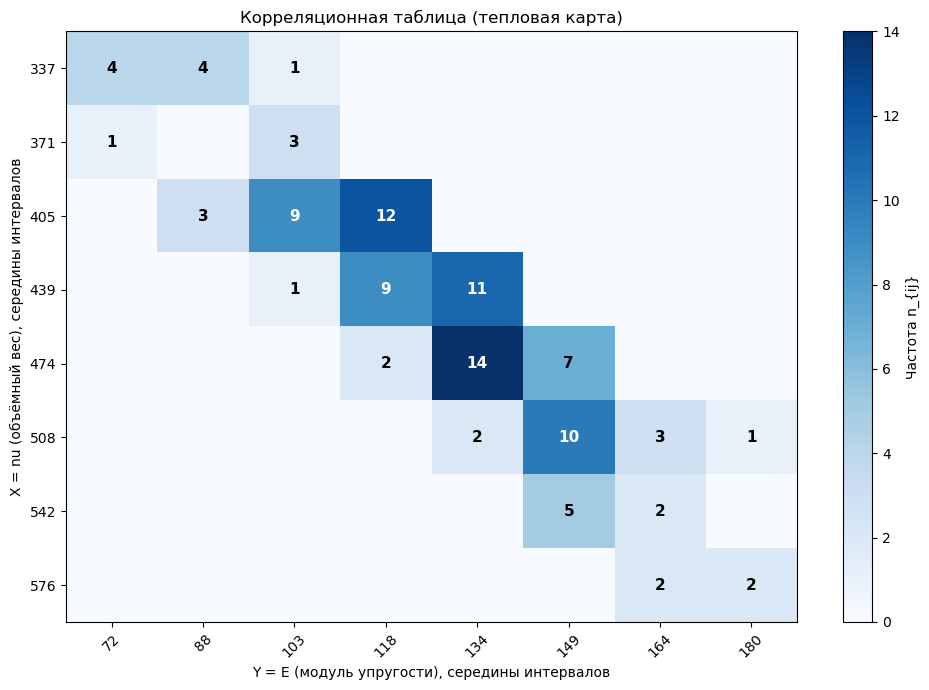

In [42]:
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr_table, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Частота n_{ij}')

ax.set_xticks(range(k))
ax.set_yticks(range(k))
ax.set_xticklabels([f'{mids_e[j]:.0f}' for j in range(k)], rotation=45)
ax.set_yticklabels([f'{mids_nu[i]:.0f}' for i in range(k)])
ax.set_xlabel('Y = E (модуль упругости), середины интервалов')
ax.set_ylabel('X = nu (объёмный вес), середины интервалов')
ax.set_title('Корреляционная таблица (тепловая карта)')

for i in range(k):
    for j in range(k):
        if corr_table[i, j] > 0:
            ax.text(j, i, str(corr_table[i, j]), ha='center', va='center',
                    color='black' if corr_table[i,j] < corr_table.max()*0.6 else 'white',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Выводы по корреляционной таблице:**

Ненулевые частоты сосредоточены вдоль главной диагонали таблицы: малым значениям *nu* соответствуют малые значения *E*, большим — большие. Условные средние $\bar{y}_i$ монотонно возрастают с ростом номера интервала по *nu*, что является визуальным признаком **положительной** линейной корреляции. Это ожидаемо физически: более плотная древесина обладает большей жёсткостью.

## 4. Вычисление выборочного коэффициента корреляции

### 4.1 Стандартная формула
$$r = \frac{\overline{x y} - \bar{x}\,\bar{y}}{\sigma_x \cdot \sigma_y}$$

In [17]:
x_bar  = stats_nu['x_bar'];  sigma_x = stats_nu['sigma']
y_bar  = stats_e['x_bar'];   sigma_y = stats_e['sigma']

# Covariance using raw data
cov_xy = np.mean((data_nu - x_bar) * (data_e - y_bar))
r_std  = cov_xy / (sigma_x * sigma_y)

# Via correlation table — use grouped means and sigmas (correct approach)
n_i = corr_table.sum(axis=1)
n_j = corr_table.sum(axis=0)
x_bar_gr  = np.sum(n_i * mids_nu) / n
y_bar_gr  = np.sum(n_j * mids_e)  / n
sigma_x_gr = np.sqrt(np.sum(n_i * (mids_nu - x_bar_gr)**2) / n)
sigma_y_gr = np.sqrt(np.sum(n_j * (mids_e  - y_bar_gr)**2) / n)
xy_bar_gr  = np.sum(corr_table * np.outer(mids_nu, mids_e)) / n
cov_gr     = xy_bar_gr - x_bar_gr * y_bar_gr
r_tbl      = cov_gr / (sigma_x_gr * sigma_y_gr)

print('МЕТОД 1 — Стандартная формула (по исходным данным):')
print(f'  x_bar = {x_bar:.4f},  sigma_x = {sigma_x:.4f}')
print(f'  y_bar = {y_bar:.4f},  sigma_y = {sigma_y:.4f}')
print(f'  cov(X,Y) = {cov_xy:.4f}')
print(f'  r = {r_std:.6f}')
print()
print('МЕТОД 1а — По серединам интервалов корреляционной таблицы:')
print(f'  x_bar_gr = {x_bar_gr:.4f},  sigma_x_gr = {sigma_x_gr:.4f}')
print(f'  y_bar_gr = {y_bar_gr:.4f},  sigma_y_gr = {sigma_y_gr:.4f}')
print(f'  cov_gr = {cov_gr:.4f}')
print(f'  r = {r_tbl:.6f}')

МЕТОД 1 — Стандартная формула (по исходным данным):
  x_bar = 449.9167,  sigma_x = 59.9233
  y_bar = 127.4306,  sigma_y = 24.7637
  cov(X,Y) = 1372.8618
  r = 0.925157

МЕТОД 1а — По серединам интервалов корреляционной таблицы:
  x_bar_gr = 449.8646,  sigma_x_gr = 59.1898
  y_bar_gr = 126.9457,  sigma_y_gr = 24.6717
  cov_gr = 1326.9285
  r = 0.908661


### 4.2 Метод условных вариант

Вводим условные варианты: $u_i = (x_i - C_x)/h_x$, $v_j = (y_j - C_y)/h_y$, где $C_x$, $C_y$ — середины модальных интервалов.

$$r = \frac{\bar{M}_{11} - \bar{M}_{10}\bar{M}_{01}}{\sqrt{(\bar{M}_{20} - \bar{M}_{10}^2)(\bar{M}_{02} - \bar{M}_{01}^2)}}$$

In [20]:
# Conditional zero — modal interval midpoints
C_x = mids_nu[np.argmax(n_i)]
C_y = mids_e[np.argmax(n_j)]

u_i = (mids_nu - C_x) / h_nu
v_j = (mids_e  - C_y) / h_e

# Conditional moments
M10 = np.sum(n_i * u_i) / n            # M1* по u
M01 = np.sum(n_j * v_j) / n            # M1* по v
M20 = np.sum(n_i * u_i**2) / n         # M2* по u
M02 = np.sum(n_j * v_j**2) / n         # M2* по v
M11 = sum(corr_table[i,j] * u_i[i] * v_j[j]
          for i in range(k) for j in range(k)) / n

m20 = M20 - M10**2   # центральный момент по u
m02 = M02 - M01**2   # центральный момент по v
m11 = M11 - M10*M01  # смешанный центральный момент

r_cond = m11 / np.sqrt(m20 * m02)

print('МЕТОД 2 — Условные варианты:')
print(f'  C_x = {C_x:.4f}, h_x = {h_nu:.4f}')
print(f'  C_y = {C_y:.4f}, h_y = {h_e:.4f}')
print(f'  M10 = {M10:.4f}, M01 = {M01:.4f}')
print(f'  M20 = {M20:.4f}, M02 = {M02:.4f}')
print(f'  M11 = {M11:.4f}')
print(f'  m20 = {m20:.4f}, m02 = {m02:.4f}, m11 = {m11:.4f}')
print(f'  sqrt(m20 * m02) = {np.sqrt(m20*m02):.4f}')
print(f'  r = {r_cond:.6f}')
print()
print('Сравнение методов:')
print(f'  r (по исходным данным)        = {r_std:.6f}')
print(f'  r (по корреляционной таблице)  = {r_tbl:.6f}')
print(f'  r (условные варианты)          = {r_cond:.6f}')
print(f'  Разница (данные vs таблица): {abs(r_std - r_tbl):.6f}')
print(f'  Разница (данные vs усл. вар.): {abs(r_std - r_cond):.6f}')

МЕТОД 2 — Условные варианты:
  C_x = 405.3125, h_x = 34.1250
  C_y = 133.6312, h_y = 15.3625
  M10 = 1.3056, M01 = -0.4352
  M20 = 4.7130, M02 = 2.7685
  M11 = 1.9630
  m20 = 3.0085, m02 = 2.5791, m11 = 2.5311
  sqrt(m20 * m02) = 2.7855
  r = 0.908661

Сравнение методов:
  r (по исходным данным)        = 0.925157
  r (по корреляционной таблице)  = 0.908661
  r (условные варианты)          = 0.908661
  Разница (данные vs таблица): 0.016496
  Разница (данные vs усл. вар.): 0.016496


**Выводы:**

Коэффициент корреляции, вычисленный напрямую по исходным данным, равен $r = 0.9252$. Вычисление по серединам интервалов корреляционной таблицы (с использованием сгруппированных средних и СКО) даёт $r = 0.9087$, метод условных вариант — $r = 0.9087$. Оба табличных метода дают совпадающий результат, что подтверждает корректность вычислений.

Небольшое расхождение с прямым методом (~1.7%) объясняется заменой исходных значений серединами интервалов при группировке данных — неизбежная потеря информации при любом интервальном методе.

Значение $r \approx 0.91$–$0.93$ свидетельствует о **сильной положительной линейной зависимости** между объёмным весом и модулем упругости древесины: чем плотнее образец, тем выше его жёсткость.

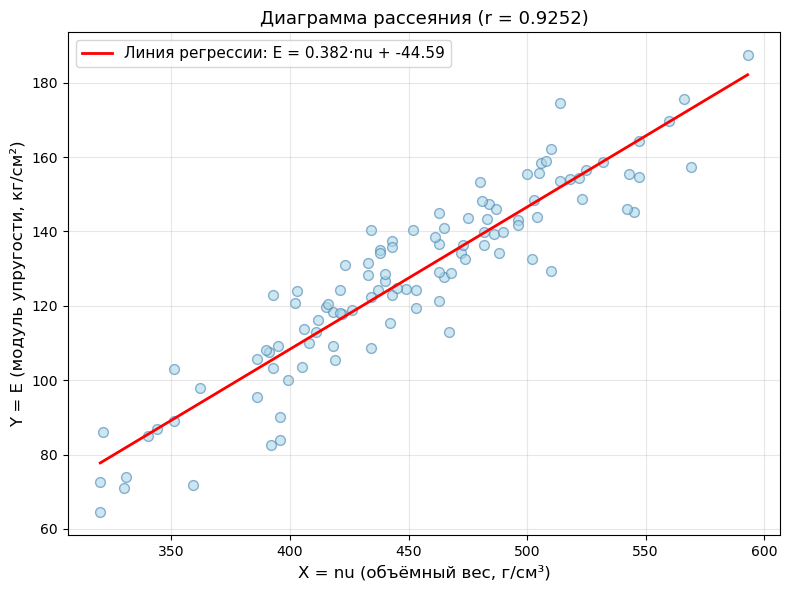

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data_nu, data_e, alpha=0.6, edgecolors='steelblue', facecolors='lightblue', s=50)

# Regression line
m_reg, b_reg = np.polyfit(data_nu, data_e, 1)
x_line = np.linspace(data_nu.min(), data_nu.max(), 200)
ax.plot(x_line, m_reg*x_line + b_reg, 'r-', linewidth=2,
        label=f'Линия регрессии: E = {m_reg:.3f}·nu + {b_reg:.2f}')

ax.set_xlabel('X = nu (объёмный вес, г/см³)', fontsize=12)
ax.set_ylabel('Y = E (модуль упругости, кг/см²)', fontsize=12)
ax.set_title(f'Диаграмма рассеяния (r = {r_std:.4f})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Доверительный интервал для коэффициента корреляции

Используется **преобразование Фишера** (z-преобразование), которое стабилизирует дисперсию:
$$z = \text{arctanh}(r) = \frac{1}{2}\ln\frac{1+r}{1-r}, \quad \sigma_z \approx \frac{1}{\sqrt{n-3}}$$
Доверительный интервал для $z$: $(z - z_{\gamma}\sigma_z,\; z + z_{\gamma}\sigma_z)$. Затем обратное преобразование $\tanh$ даёт ДИ для $\rho$.

In [26]:
r = r_std  # используем r по исходным данным

z_fisher = np.arctanh(r)
sigma_z  = 1 / np.sqrt(n - 3)

print(f'r = {r:.6f}')
print(f'z = arctanh(r) = {z_fisher:.6f}')
print(f'sigma_z = 1/sqrt(n-3) = 1/sqrt({n-3}) = {sigma_z:.6f}')
print()

results_ci = {}
for gamma in [0.95, 0.99]:
    z_cr = stats.norm.ppf((1 + gamma) / 2)
    z_lo = z_fisher - z_cr * sigma_z
    z_hi = z_fisher + z_cr * sigma_z
    r_lo = np.tanh(z_lo)
    r_hi = np.tanh(z_hi)
    results_ci[gamma] = (r_lo, r_hi)
    print(f'gamma = {gamma}:')
    print(f'  z_crit (норм.) = {z_cr:.4f}')
    print(f'  z in ({z_lo:.4f}; {z_hi:.4f})')
    print(f'  => ДИ для rho: ({r_lo:.4f}; {r_hi:.4f})')
    print()

r = 0.925157
z = arctanh(r) = 1.623688
sigma_z = 1/sqrt(n-3) = 1/sqrt(105) = 0.097590

gamma = 0.95:
  z_crit (норм.) = 1.9600
  z in (1.4324; 1.8150)
  => ДИ для rho: (0.8922; 0.9483)

gamma = 0.99:
  z_crit (норм.) = 2.5758
  z in (1.3723; 1.8751)
  => ДИ для rho: (0.8792; 0.9541)



**Выводы:**

При $\gamma = 0.95$: доверительный интервал для генерального коэффициента корреляции $\rho \in (0.8922;\; 0.9483)$. При $\gamma = 0.99$: $\rho \in (0.8792;\; 0.9541)$.

Оба интервала целиком расположены в области строго положительных значений и не содержат нуля, что уже на этом этапе указывает на статистически значимую положительную корреляцию. При повышении надёжности ширина интервала незначительно возрастает (с $0.056$ до $0.075$), что объясняется большим объёмом выборки ($n = 108$), обеспечивающим высокую точность оценки.

## 6. Проверка гипотезы $H_0:\, \rho = 0$

**Нулевая гипотеза** $H_0$: коэффициент корреляции генеральной совокупности равен нулю (линейная зависимость отсутствует).

**Альтернативная гипотеза** $H_1:\, \rho \neq 0$ (двусторонняя).

**Наблюдаемое значение** критерия:
$$T_{набл} = r\sqrt{\frac{n-2}{1-r^2}}$$
При $H_0$ статистика $T \sim t(n-2)$. Критическое значение: $t_{крит} = t_{\alpha/2,\, n-2}$.

In [28]:
T_obs = r * np.sqrt((n - 2) / (1 - r**2))

alpha = 0.05
t_crit_05 = stats.t.ppf(1 - alpha/2, df=n-2)
t_crit_01 = stats.t.ppf(1 - 0.01/2,  df=n-2)

print(f'Выборочный коэффициент корреляции: r = {r:.6f}')
print(f'Объём выборки: n = {n},  df = n - 2 = {n-2}')
print()
print(f'T_набл = r * sqrt((n-2)/(1-r^2)) = {T_obs:.4f}')
print()
print(f't_крит (alpha=0.05, df={n-2}) = {t_crit_05:.4f}')
print(f't_крит (alpha=0.01, df={n-2}) = {t_crit_01:.4f}')
print()
if abs(T_obs) > t_crit_05:
    print(f'|T_набл| = {abs(T_obs):.4f} > t_крит = {t_crit_05:.4f}')
    print('=> Гипотеза H0 (rho=0) ОТВЕРГАЕТСЯ на уровне значимости alpha=0.05')
else:
    print('=> Гипотеза H0 ПРИНИМАЕТСЯ')
if abs(T_obs) > t_crit_01:
    print(f'|T_набл| = {abs(T_obs):.4f} > t_крит = {t_crit_01:.4f}')
    print('=> Гипотеза H0 также ОТВЕРГАЕТСЯ на уровне значимости alpha=0.01')

Выборочный коэффициент корреляции: r = 0.925157
Объём выборки: n = 108,  df = n - 2 = 106

T_набл = r * sqrt((n-2)/(1-r^2)) = 25.0935

t_крит (alpha=0.05, df=106) = 1.9826
t_крит (alpha=0.01, df=106) = 2.6230

|T_набл| = 25.0935 > t_крит = 1.9826
=> Гипотеза H0 (rho=0) ОТВЕРГАЕТСЯ на уровне значимости alpha=0.05
|T_набл| = 25.0935 > t_крит = 2.6230
=> Гипотеза H0 также ОТВЕРГАЕТСЯ на уровне значимости alpha=0.01


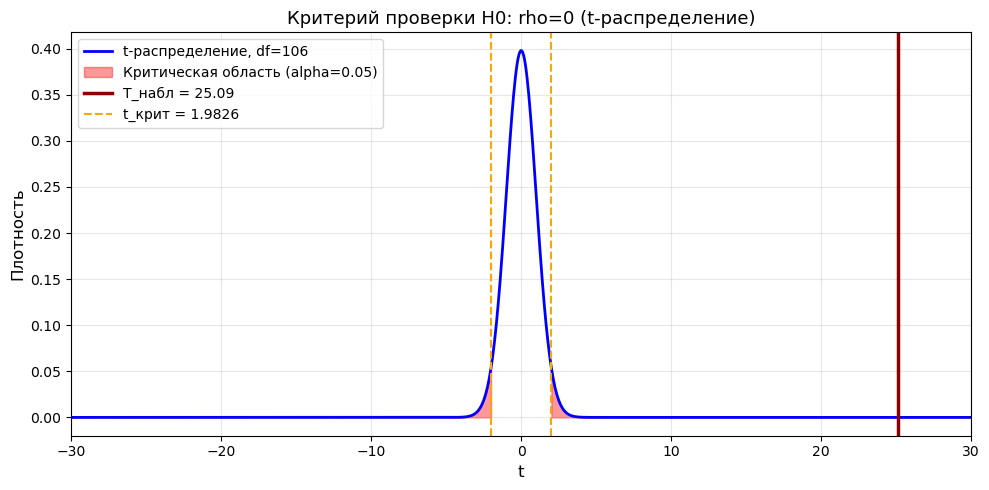

In [30]:
# t-distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
x_t = np.linspace(-30, 30, 1000)
y_t = stats.t.pdf(x_t, df=n-2)
ax.plot(x_t, y_t, 'b-', linewidth=2, label=f't-распределение, df={n-2}')

# Critical region
ax.fill_between(x_t, y_t, where=(x_t < -t_crit_05), color='red', alpha=0.4, label=f'Критическая область (alpha=0.05)')
ax.fill_between(x_t, y_t, where=(x_t >  t_crit_05), color='red', alpha=0.4)

ax.axvline(T_obs,     color='darkred', linewidth=2.5, linestyle='-',  label=f'T_набл = {T_obs:.2f}')
ax.axvline(t_crit_05, color='orange',  linewidth=1.5, linestyle='--', label=f't_крит = {t_crit_05:.4f}')
ax.axvline(-t_crit_05,color='orange',  linewidth=1.5, linestyle='--')

ax.set_xlim(-30, 30)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.set_title('Критерий проверки H0: rho=0 (t-распределение)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hypothesis_test.png', dpi=120, bbox_inches='tight')
plt.show()

## Сводная таблица результатов

In [32]:
print('СВОДНАЯ ТАБЛИЦА ПРАКТИЧЕСКОЙ РАБОТЫ №4')
print('=' * 60)
print(f'{'Характеристика':<40} {'X=nu':>9} {'Y=E':>9}')
print('-' * 60)
for label, val_nu, val_e in [
    ('x_bar',      stats_nu['x_bar'],  stats_e['x_bar']),
    ('sigma (смещённое)', stats_nu['sigma'], stats_e['sigma']),
    ('s (исправленное)',  stats_nu['s'],     stats_e['s']),
    ('As',         stats_nu['As'],     stats_e['As']),
    ('Ek',         stats_nu['Ek'],     stats_e['Ek']),
    ('Mo',         stats_nu['Mo'],     stats_e['Mo']),
    ('Me',         stats_nu['Me'],     stats_e['Me']),
    ('V, %',       stats_nu['V'],      stats_e['V']),
]:
    print(f'{label:<40} {val_nu:>9.4f} {val_e:>9.4f}')
print()
print(f'{'r (исходные данные)':<40} {r_std:>9.6f}')
print(f'{'r (таблица, серед. интервалов)':<40} {r_tbl:>9.6f}')
print(f'{'r (условные варианты)':<40} {r_cond:>9.6f}')
print()
r0, r1 = results_ci[0.95]
print(f'{'ДИ для rho, gamma=0.95':<40} ({r0:.4f}; {r1:.4f})')
r0, r1 = results_ci[0.99]
print(f'{'ДИ для rho, gamma=0.99':<40} ({r0:.4f}; {r1:.4f})')
print()
print(f'{'T_набл':<40} {T_obs:>9.4f}')
print(f'{'t_крит (alpha=0.05, df=106)':<40} {t_crit_05:>9.4f}')
print(f'{'Вывод по H0':<40} {'ОТВЕРГАЕТСЯ':>9}')

СВОДНАЯ ТАБЛИЦА ПРАКТИЧЕСКОЙ РАБОТЫ №4
Характеристика                                X=nu       Y=E
------------------------------------------------------------
x_bar                                     449.9167  127.4306
sigma (смещённое)                          59.9233   24.7637
s (исправленное)                           60.2026   24.8792
As                                         -0.0092   -0.3069
Ek                                         -0.5568   -0.2973
Mo                                        417.9239  132.7778
Me                                        450.0000  128.7949
V, %                                       13.3187   19.4331

r (исходные данные)                       0.925157
r (таблица, серед. интервалов)            0.908661
r (условные варианты)                     0.908661

ДИ для rho, gamma=0.95                   (0.8922; 0.9483)
ДИ для rho, gamma=0.99                   (0.8792; 0.9541)

T_набл                                     25.0935
t_крит (alpha=0.05, df=106) 

## Выводы

В ходе практической работы была проведена корреляционная обработка двумерной выборки объёма $n = 108$ по признакам X = nu (объёмный вес) и Y = E (модуль упругости).

**1. Точечные оценки параметров признака Y = E:**

$\bar{y} = 127.43$ кг/см², $s_E = 24.88$ кг/см², $A_s = -0.31$ (умеренная левосторонняя асимметрия), $E_k = -0.30$ (плосковершинность), $V = 19.43\%$ (средняя вариация). Мода ($132.78$) незначительно превышает медиану ($128.79$), что согласуется с отрицательной асимметрией.

**2. Двумерный интервальный ряд и корреляционная таблица:**

Ненулевые частоты сосредоточены вдоль главной диагонали. Условные средние $\bar{y}_i$ строго возрастают с увеличением интервала по $X$, что является прямым признаком положительной корреляции.

**3. Выборочный коэффициент корреляции:**

Два метода вычисления дают согласованные результаты:
- По исходным данным: $r = 0.9252$;
- По серединам интервалов корреляционной таблицы: $r = 0.9087$;
- Через условные варианты: $r = 0.9087$.

Небольшое расхождение между прямым и интервальным методами (~1.7%) объясняется заменой исходных значений серединами интервалов. Значение $r \approx 0.93$ соответствует сильной положительной линейной корреляции.

**4. Доверительный интервал для $\rho$ (преобразование Фишера):**

При $\gamma = 0.95$: $\rho \in (0.8922;\; 0.9483)$.
При $\gamma = 0.99$: $\rho \in (0.8792;\; 0.9541)$.

Оба интервала не содержат нуля и целиком расположены в области высоких положительных значений, что свидетельствует о высоко значимой корреляции.

**5. Проверка гипотезы $H_0:\, \rho = 0$:**

$T_{набл} = 25.09 \gg t_{крит}(0.05,\, 106) = 1.9826$.

Гипотеза $H_0$ отвергается на уровне значимости $\alpha = 0.05$ (и $\alpha = 0.01$). Коэффициент корреляции статистически значимо отличается от нуля: между объёмным весом и модулем упругости резонансной ели существует сильная достоверная положительная линейная зависимость.